# Visualise Scores for LLM-vs-LMM Experiments

## 1. Imports & Plot Utils 

In [32]:
# === SETUP ===

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional, Any, Union, Iterable

# show full tables if you print heads
pd.set_option("display.max_columns", 200)

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

LLM1_PATH = BASE_DIR /"src"/ "data" / "scores" / "user_scores_partial.parquet"
guesses = BASE_DIR /"src"/ "data" / "conversations" / "investigator_guesses_partial.jsonl"

assert LLM1_PATH.exists(), f"Missing: {LLM1_PATH}"
assert guesses.exists(), f"Missing: {guesses}"

df_u = pd.read_parquet(LLM1_PATH)
investigator_guesses = pd.read_json(guesses, lines=True)

print("LLM1 DF:", df_u.shape, df_u.columns.tolist())

display(df_u.head(3))
print("Investigator Guesses DF:", investigator_guesses.shape, investigator_guesses.columns.tolist())

LLM1 DF: (450, 9) ['conversation_idx', 'persona_id', 'base_persona_id', 'style_id', 'investigator_mode', 'user_turn_idx', 'avg_nll', 'num_tokens', 'ppl']


,conversation_idx,persona_id,base_persona_id,style_id,investigator_mode,user_turn_idx,avg_nll,num_tokens,ppl
0,0,bp_tech_starter__st_formal__inv_none,bp_tech_starter,st_formal,none,0,2.610193,27,13.601682
1,0,bp_tech_starter__st_formal__inv_none,bp_tech_starter,st_formal,none,1,2.055135,19,7.807890
2,0,bp_tech_starter__st_formal__inv_none,bp_tech_starter,st_formal,none,2,3.622870,17,37.444897


Investigator Guesses DF: (231, 9) ['conversation_id', 'persona_id', 'investigator_mode', 'experiment_index', 'replicate_index', 'turn_idx', 'guess', 'confidence', 'raw_line']


In [33]:
# === QUICK SANITY CHECKS ===

def sanity(df: pd.DataFrame, turn_col: str, name: str):
    print(f"\n--- {name} ---")
    print("unique base_persona_id:", df["base_persona_id"].nunique(), sorted(df["base_persona_id"].unique()))
    print("unique style_id:", df["style_id"].nunique(), sorted(df["style_id"].unique()))
    print("turn_col:", turn_col, "min/max:", int(df[turn_col].min()), int(df[turn_col].max()))
    print("avg_nll min/max:", float(df["avg_nll"].min()), float(df["avg_nll"].max()))

sanity(df_u, "user_turn_idx", "LLM1/USER")


--- LLM1/USER ---
unique base_persona_id: 1 ['bp_tech_starter']
unique style_id: 5 ['st_blunt', 'st_formal', 'st_rambler', 'st_skeptical', 'st_warm']
turn_col: user_turn_idx min/max: 0 5
avg_nll min/max: 0.3025202453136444 3.9366841316223145


In [34]:
# === SCORE PLOTTING HELPERS ===

def _mask_from_filters(df: pd.DataFrame, filters: Optional[Dict[str, Any]] = None) -> pd.Series:
    """
    Build a boolean mask from filters like:
      {"base_persona_id": "bp_x", "style_id": ["st_formal", "st_warm"], "investigator_mode": "none"}
    """
    if not filters:
        return pd.Series(True, index=df.index)

    mask = pd.Series(True, index=df.index)
    for col, val in filters.items():
        if col not in df.columns:
            raise KeyError(f"Filter column '{col}' not in df.columns")

        if isinstance(val, (list, tuple, set)):
            mask &= df[col].isin(list(val))
        else:
            mask &= (df[col] == val)

    return mask


def _mean_curve_equal_weight_conversations(
    df: pd.DataFrame,
    *,
    group_cols: List[str],
    turn_col: str,
    y_col: str,
    conv_col: str = "conversation_idx", 
    ) -> pd.DataFrame:
    """
    Equal-weight conversations:
      1) mean within each conversation for each (group_cols, turn)
      2) mean across conversations for each (group_cols, turn)
    Returns tidy df: group_cols + [turn_col, "mean_y"]
    """
    # Step 1: per-conversation curve (already 1 row per turn per conv, but robust if duplicates exist)
    per_conv = (
        df.groupby(group_cols + [conv_col, turn_col], as_index=False)[y_col]
          .mean()
          .rename(columns={y_col: "y"})
    )

    # Step 2: average across conversations
    mean_df = (
        per_conv.groupby(group_cols + [turn_col], as_index=False)["y"]
               .mean()
               .rename(columns={"y": "mean_y"})
    )

    return mean_df


def plot_avg_by_group(
    df: pd.DataFrame,
    *,
    group_col: str,
    filters: Optional[Dict[str, Any]] = None,
    turn_col: str = "user_turn_idx",
    y_col: str = "avg_nll",
    conv_col: str = "conversation_idx",
    title: Optional[str] = None,
    show_legend: bool = True,
    ):
    """
    One figure. One line per group_col value.
    Example:
      plot_avg_by_group(df_u, group_col="style_id", filters={"base_persona_id": "bp_tech_starter"})
    """
    sub = df[_mask_from_filters(df, filters)].copy()
    if sub.empty:
        print("[plot_avg_by_group] empty after filtering:", filters)
        return

    if group_col not in sub.columns:
        raise KeyError(f"group_col '{group_col}' not found in dataframe columns")

    mean_df = _mean_curve_equal_weight_conversations(
        sub,
        group_cols=[group_col],
        turn_col=turn_col,
        y_col=y_col,
        conv_col=conv_col,
    )

    # pivot wide: index=turn, columns=group value
    wide = mean_df.pivot(index=turn_col, columns=group_col, values="mean_y").sort_index()

    plt.figure(figsize=(10, 5))
    for col in wide.columns:
        plt.plot(wide.index, wide[col], marker="o", linewidth=2, label=str(col))

    if title is None:
        title = f"Mean {y_col} by {group_col}"
        if filters:
            title += f" | filters={filters}"

    plt.title(title)
    plt.xlabel("Turn index")
    plt.ylabel(f"Mean {y_col} (across conversations)")
    plt.xticks(wide.index)
    plt.grid(True, alpha=0.3)
    if show_legend:
        plt.legend(title=group_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_conversation_curves_with_mean(
    df: pd.DataFrame,
    *,
    config_filters: Dict[str, Any],
    turn_col: str = "user_turn_idx",
    y_col: str = "avg_nll",
    conv_col: str = "conversation_idx",
    title: Optional[str] = None,
    alpha_individual: float = 0.25,
    linewidth_individual: float = 1.5,
    linewidth_mean: float = 3.0,
    ):
    """
    One figure for ONE configuration (e.g., base_persona_id+style_id+investigator_mode).
    - plots each conversation curve (faint)
    - plots mean curve (bold)
    """
    sub = df[_mask_from_filters(df, config_filters)].copy()
    if sub.empty:
        print("[plot_conversation_curves_with_mean] empty after filtering:", config_filters)
        return

    # individual curves
    plt.figure(figsize=(10, 5))
    conv_ids = sorted(sub[conv_col].unique())

    for cid in conv_ids:
        one = sub[sub[conv_col] == cid].sort_values(turn_col)
        # if missing turns, matplotlib will just connect existing points; that's ok
        plt.plot(
            one[turn_col].values,
            one[y_col].values,
            marker="o",
            linewidth=linewidth_individual,
            alpha=alpha_individual,
        )

    # mean curve (equal-weight conversations)
    mean_df = _mean_curve_equal_weight_conversations(
        sub,
        group_cols=[],  # no grouping besides "this config"
        turn_col=turn_col,
        y_col=y_col,
        conv_col=conv_col,
    )
    mean_df = mean_df.sort_values(turn_col)

    # draw mean line last so it's on top
    plt.plot(
        mean_df[turn_col].values,
        mean_df["mean_y"].values,
        marker="o",
        linewidth=linewidth_mean,
        linestyle="-",
        label="Mean",
    )

    if title is None:
        title = f"Per-conversation curves + mean | config={config_filters}"

    plt.title(title)
    plt.xlabel("Turn index")
    plt.ylabel(y_col)
    plt.xticks(sorted(sub[turn_col].unique()))
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [42]:
# === INVESTIGATOR GUESSES HELPERS ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Dict, Any

def add_truth_cols_from_persona_id(df: pd.DataFrame) -> pd.DataFrame:
    """
    persona_id format: base__style__inv_mode (e.g., bp_tech_starter__st_formal__inv_guided)
    Adds: true_base_persona_id, true_style_id, true_investigator_mode
    """
    out = df.copy()
    parts = out["persona_id"].astype(str).str.split("__", expand=True)
    out["true_base_persona_id"] = parts[0]
    out["true_style_id"] = parts[1]
    out["true_investigator_mode"] = parts[2].str.replace("^inv_", "", regex=True)
    return out

def _mask_from_filters(df: pd.DataFrame, filters: Optional[Dict[str, Any]] = None) -> pd.Series:
    if not filters:
        return pd.Series(True, index=df.index)
    mask = pd.Series(True, index=df.index)
    for col, val in filters.items():
        if isinstance(val, (list, tuple, set)):
            mask &= df[col].isin(list(val))
        else:
            mask &= (df[col] == val)
    return mask

def prep_guided_style_accuracy(investigator_guesses: pd.DataFrame) -> pd.DataFrame:
    """
    Guided-only, style-guess accuracy.
    Creates boolean 'correct' where guess == true_style_id.
    """
    g = add_truth_cols_from_persona_id(investigator_guesses)
    g = g[g["investigator_mode"] == "guided"].copy()

    # normalize strings
    g["guess"] = g["guess"].astype(str).str.strip()
    g["true_style_id"] = g["true_style_id"].astype(str).str.strip()

    g["correct"] = (g["guess"] == g["true_style_id"])
    return g

def plot_investigator_accuracy_bar(
    investigator_guesses: pd.DataFrame,
    *,
    group_col: str = "true_style_id",
    filters: Optional[Dict[str, Any]] = None,
    title: Optional[str] = None,
):
    """
    Bar chart: accuracy = correct/total per group.
    Annotates n per bar.
    """
    g = prep_guided_style_accuracy(investigator_guesses)
    g = g[_mask_from_filters(g, filters)].copy()
    if g.empty:
        print("[plot_investigator_accuracy_bar] empty after filtering:", filters)
        return

    agg = (
        g.groupby(group_col, as_index=False)
         .agg(total=("correct", "size"), correct=("correct", "sum"))
    )
    agg["accuracy"] = agg["correct"] / agg["total"]
    agg = agg.sort_values(group_col)

    plt.figure(figsize=(10, 4.5))
    plt.bar(agg[group_col].astype(str), agg["accuracy"].values)
    plt.ylim(0, 1.0)
    plt.ylabel("Accuracy (correct / total)")
    plt.xlabel(group_col)

    for i, row in agg.reset_index(drop=True).iterrows():
        plt.text(i, 0.02, f"n={int(row['total'])}", ha="center", va="bottom", fontsize=9)

    if title is None:
        title = f"Investigator accuracy by {group_col} (guided only)"
        if filters:
            title += f" | filters={filters}"
    plt.title(title)

    plt.xticks(rotation=35, ha="right")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

def plot_investigator_accuracy_over_turns(
    investigator_guesses: pd.DataFrame,
    *,
    line_col: str = "true_style_id",
    filters: Optional[Dict[str, Any]] = None,
    title: Optional[str] = None,
):
    """
    Line chart: accuracy by assistant turn_idx, with one line per line_col group.
    """
    g = prep_guided_style_accuracy(investigator_guesses)
    g = g[_mask_from_filters(g, filters)].copy()
    if g.empty:
        print("[plot_investigator_accuracy_over_turns] empty after filtering:", filters)
        return

    agg = (
        g.groupby(["turn_idx", line_col], as_index=False)
         .agg(total=("correct", "size"), correct=("correct", "sum"))
    )
    agg["accuracy"] = agg["correct"] / agg["total"]
    wide = agg.pivot(index="turn_idx", columns=line_col, values="accuracy").sort_index()

    plt.figure(figsize=(10, 4.5))
    for col in wide.columns:
        plt.plot(wide.index, wide[col], marker="o", linewidth=2, label=str(col))

    plt.ylim(0, 1.0)
    plt.xlabel("Assistant turn_idx (where guess is produced)")
    plt.ylabel("Accuracy")

    if title is None:
        title = f"Investigator accuracy over turns | lines={line_col} (guided only)"
        if filters:
            title += f" | filters={filters}"
    plt.title(title)

    plt.xticks(sorted(wide.index.unique()))
    plt.grid(True, alpha=0.25)
    plt.legend(title=line_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 2. Hidden Personas with Styles (Scoring User Turns)

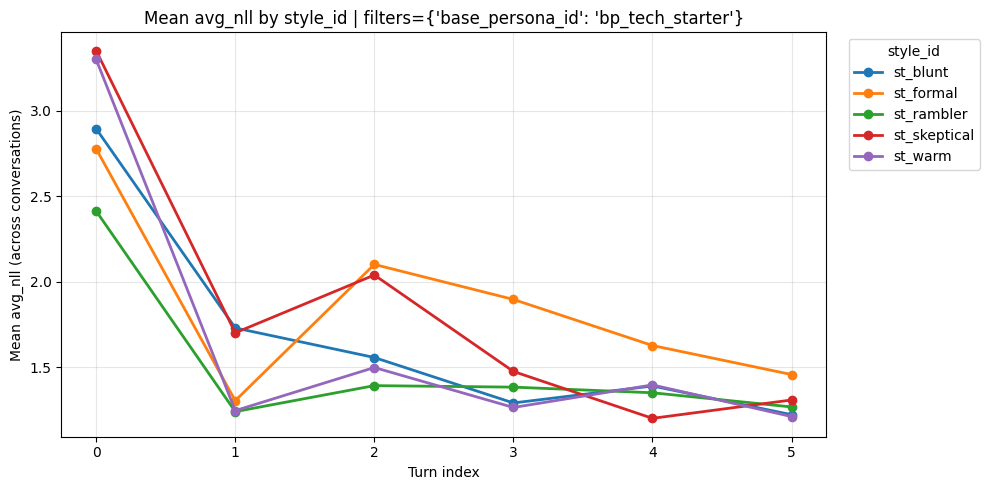

In [36]:
plot_avg_by_group(
    df_u,
    group_col="style_id",
    filters={"base_persona_id": "bp_tech_starter"},
)

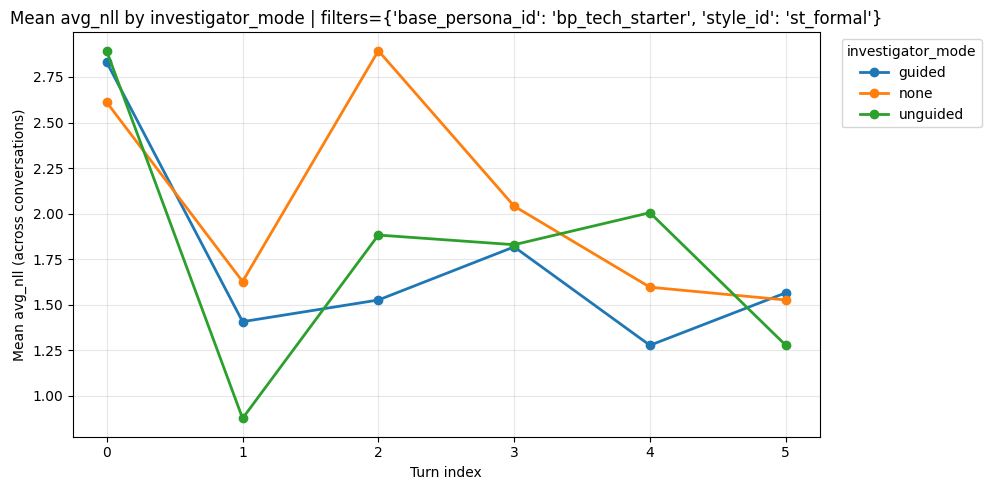

In [37]:
plot_avg_by_group(
    df_u,
    group_col="investigator_mode",
    filters={"base_persona_id": "bp_tech_starter", "style_id": "st_formal"},
)

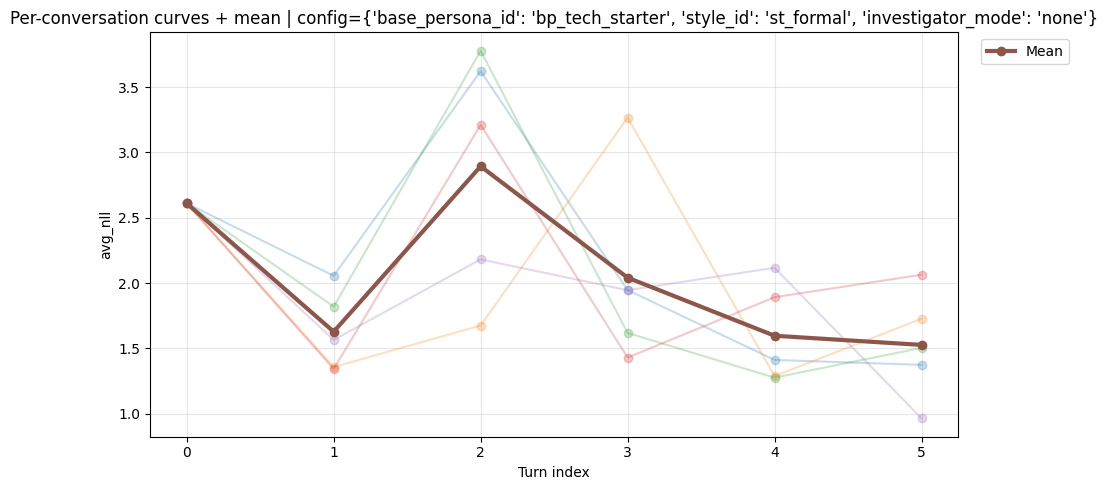

In [38]:
plot_conversation_curves_with_mean(
    df_u,
    config_filters={
        "base_persona_id": "bp_tech_starter",
        "style_id": "st_formal",
        "investigator_mode": "none",
    }
)

## 3. Investigator Guesses

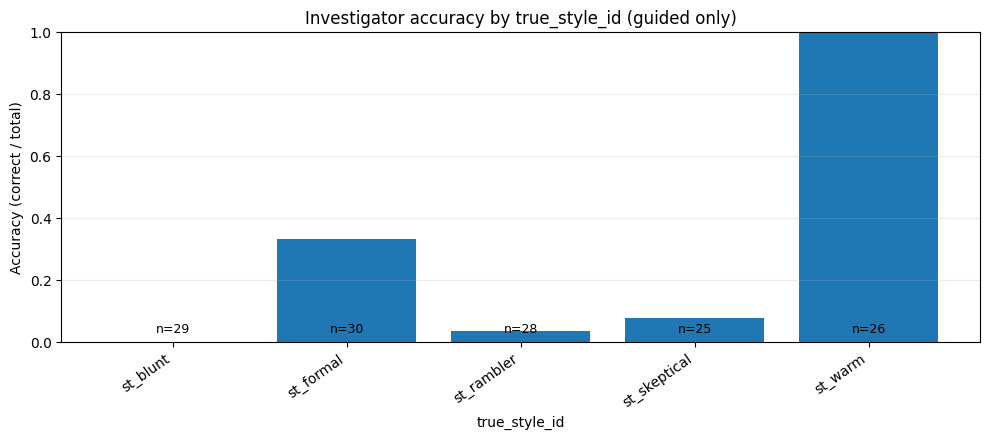

In [44]:
plot_investigator_accuracy_bar(investigator_guesses, group_col="true_style_id")

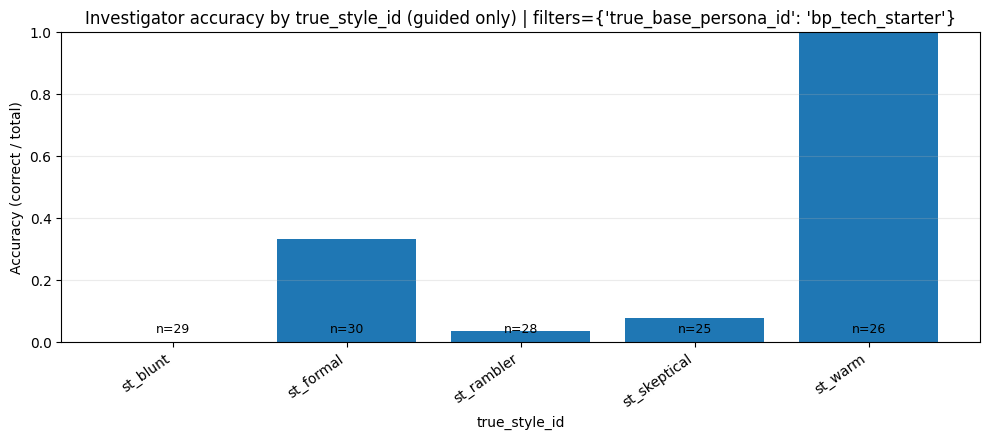

In [45]:
plot_investigator_accuracy_bar(
    investigator_guesses,
    group_col="true_style_id",
    filters={"true_base_persona_id": "bp_tech_starter"},
)

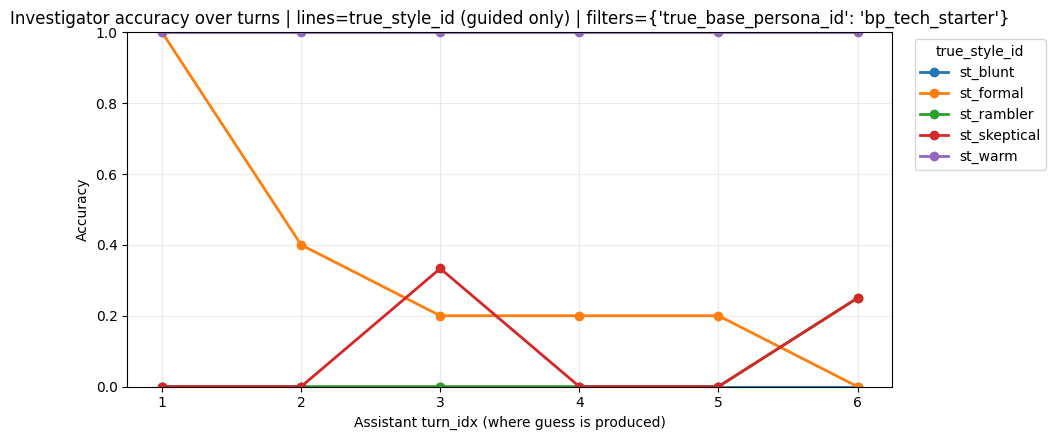

In [46]:
plot_investigator_accuracy_over_turns(
    investigator_guesses,
    line_col="true_style_id",
    filters={"true_base_persona_id": "bp_tech_starter"},
)